In [1]:
import pandas as pd 
import numpy as np

In [2]:
data=pd.read_csv('btc.csv')

In [3]:
data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,7200.17431640625,7254.33056640625,7174.9443359375,7194.89208984375,18565664997
3,2020-01-02,6985.47021484375,7212.1552734375,6935.27001953125,7202.55126953125,20802083465
4,2020-01-03,7344.88427734375,7413.71533203125,6914.99609375,6984.4287109375,28111481032


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2325 non-null   object
 1   Close   2324 non-null   object
 2   High    2324 non-null   object
 3   Low     2324 non-null   object
 4   Open    2324 non-null   object
 5   Volume  2324 non-null   object
dtypes: object(6)
memory usage: 109.1+ KB


In [5]:
data.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [6]:
data.shape

(2325, 6)

In [7]:
data=data.dropna()

In [8]:
data.isnull().sum()

Price     0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [11]:
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data['Returns']=data['Close'].pct_change()

In [13]:
data['Volatility'] = data['Returns'].rolling(7).std()
data.head()

,Price,Close,High,Low,Open,Volume,Returns,Volatility
0,Ticker,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,NaN,NaN
2,2020-01-01,7200.174316,7254.33056640625,7174.9443359375,7194.89208984375,18565664997,NaN,NaN
3,2020-01-02,6985.470215,7212.1552734375,6935.27001953125,7202.55126953125,20802083465,-0.029819,NaN
4,2020-01-03,7344.884277,7413.71533203125,6914.99609375,6984.4287109375,28111481032,0.051452,NaN
5,2020-01-04,7410.656738,7427.3857421875,7309.51416015625,7345.37548828125,18444271275,0.008955,NaN


In [15]:
data.head(20)

,Price,Close,High,Low,Open,Volume,Returns,Volatility
0,Ticker,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,NaN,NaN
2,2020-01-01,7200.174316,7254.33056640625,7174.9443359375,7194.89208984375,18565664997,NaN,NaN
3,2020-01-02,6985.470215,7212.1552734375,6935.27001953125,7202.55126953125,20802083465,-0.029819,NaN
4,2020-01-03,7344.884277,7413.71533203125,6914.99609375,6984.4287109375,28111481032,0.051452,NaN
5,2020-01-04,7410.656738,7427.3857421875,7309.51416015625,7345.37548828125,18444271275,0.008955,NaN
6,2020-01-05,7411.317383,7544.4970703125,7400.53564453125,7410.45166015625,19725074095,0.000089,NaN
7,2020-01-06,7769.219238,7781.8671875,7409.29296875,7410.4521484375,23276261598,0.048291,NaN
8,2020-01-07,8163.692383,8178.2158203125,7768.2275390625,7768.68212890625,28767291327,0.050774,NaN
9,2020-01-08,8079.862793,8396.73828125,7956.7744140625,8161.935546875,31672559265,-0.010269,0.033149
10,2020-01-09,7879.071289,8082.2958984375,7842.40380859375,8082.2958984375,24045990466,-0.024851,0.032011


In [24]:
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands

data['RSI'] = RSIIndicator(data['Close']).rsi()
MACD=MACD(data['Close'])
data['MACD'] = MACD.macd()

BB=BollingerBands(data['Close'])
data['BB_High'] = BB.bollinger_hband()      
data['BB_Low'] = BB.bollinger_lband()

In [26]:
data['Volatility_Lag1'] = data['Volatility'].shift(1)
data['Volatility_Lag2'] = data['Volatility'].shift(2)
data['Volatility_Lag3'] = data['Volatility'].shift(3)

data['Return_Lag1'] = data['Returns'].shift(1)
data['Return_Lag2'] = data['Returns'].shift(2)

In [28]:
data.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Volatility', 'RSI', 'MACD', 'BB_High', 'BB_Low', 'Volatility_Lag1',
       'Volatility_Lag2', 'Volatility_Lag3', 'Return_Lag1', 'Return_Lag2'],
      dtype='object')

In [29]:
data.head()

,Price,Close,High,Low,Open,Volume,Returns,Volatility,RSI,MACD,BB_High,BB_Low,Volatility_Lag1,Volatility_Lag2,Volatility_Lag3,Return_Lag1,Return_Lag2
55,2020-02-23,9924.515625,9937.404296875,9657.791015625,9663.318359375,41185185761,0.027044,0.031893,54.251757,68.398142,10431.335523,9307.796606,0.029814,0.033090,0.033216,-0.002401,0.008114
56,2020-02-24,9650.174805,9951.74609375,9537.04296875,9921.5830078125,45080496648,-0.027643,0.032308,48.014757,49.813799,10370.703292,9415.350028,0.031893,0.029814,0.033090,0.027044,-0.002401
57,2020-02-25,9341.705078,9652.7373046875,9305.021484375,9651.3125,42515259129,-0.031965,0.026475,42.147436,10.078466,10401.544355,9357.337091,0.032308,0.031893,0.029814,-0.027643,0.027044
58,2020-02-26,8820.522461,9354.7783203125,8704.4267578125,9338.2900390625,50420050762,-0.055791,0.027900,34.480804,-62.743881,10529.755118,9138.198397,0.026475,0.032308,0.031893,-0.031965,-0.027643
59,2020-02-27,8784.494141,8932.892578125,8577.19921875,8825.09375,45470195695,-0.004085,0.027820,34.020115,-121.957450,10616.393298,8950.415295,0.027900,0.026475,0.032308,-0.055791,-0.031965


In [30]:
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'RSI',
    'MACD',
    'BB_High',
    'BB_Low',
    'Volatility_Lag1',
    'Volatility_Lag2',
    'Volatility_Lag3',
    'Return_Lag1',
    'Return_Lag2'
    
]

target = 'Volatility'

data = data.dropna()

X = data[features]
y = data[target]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
predictions = model.predict(X_test)


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.004410176257318929
RMSE: 0.007621892368906235
R2 Score: 0.8068280993675825


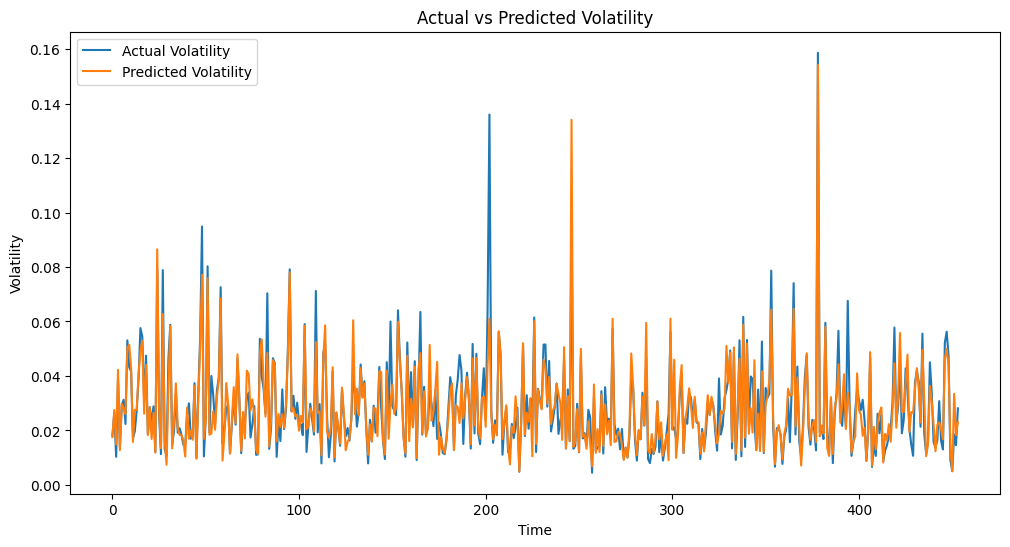

In [47]:
import matplotlib.pyplot as plt

# Plot size
plt.figure(figsize=(12,6))

# Actual values
plt.plot(y_test.values, label='Actual Volatility')

# Predicted values
plt.plot(predictions, label='Predicted Volatility')

# Labels
plt.xlabel('Time')
plt.ylabel('Volatility')

# Title
plt.title('Actual vs Predicted Volatility')

# Legend
plt.legend()

# Show graph
plt.show()

In [49]:
import joblib

joblib.dump(model,"volatility_model.pkl")

['volatility_model.pkl']